<a href="https://colab.research.google.com/github/beyzahiz/Sentiment-Analysis-NLP/blob/main/04_lstm_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("IMDB Dataset.csv")

In [13]:
df['sentiment'] = df['sentiment'].map({
    'positive':1,
    'negative':0
})

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [15]:
#Tokenizer: Deep learning modelleri kelime indexleri ile çalışır

from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

#text -> sayı
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [16]:
#Padding: Cümlelerin uzunluğu farklıdır, hepsini aynı boyuta getirmek

from tensorflow.keras.preprocessing.sequence import pad_sequences
max_length = 200

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

In [17]:
from tensorflow.keras.layers import Bidirectional, Dropout, GlobalMaxPooling1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential()
model.add(Embedding(10000, 128))
model.add(Bidirectional(LSTM(64, return_sequences=True)))  #cümleyi hem baştan sona hem de sondan başa okur
model.add(GlobalMaxPooling1D())  #cümledeki en belirgin özellikleri seçer, karmaşıklığı azaltır, modelin en önemli kelimelere odaklanmasını sağlar
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=4,
    batch_size=64,
    validation_split=0.2
)

loss, accuracy = model.evaluate(X_test_pad, y_test)
print("Test Accuracy: ", accuracy)

Epoch 1/4
500/500 ━━━━━━━━━━━━━━━━━━━━ 215s 423ms/step - accuracy: 0.7882 - loss: 0.4361 - val_accuracy: 0.8701 - val_loss: 0.3001
Epoch 2/4
500/500 ━━━━━━━━━━━━━━━━━━━━ 209s 419ms/step - accuracy: 0.9014 - loss: 0.2486 - val_accuracy: 0.8806 - val_loss: 0.2891
Epoch 3/4
500/500 ━━━━━━━━━━━━━━━━━━━━ 216s 433ms/step - accuracy: 0.9270 - loss: 0.1917 - val_accuracy: 0.8806 - val_loss: 0.2918
Epoch 4/4
500/500 ━━━━━━━━━━━━━━━━━━━━ 258s 424ms/step - accuracy: 0.9403 - loss: 0.1586 - val_accuracy: 0.8800 - val_loss: 0.3185
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.8816 - loss: 0.3132
Test Accuracy:  0.881600022315979


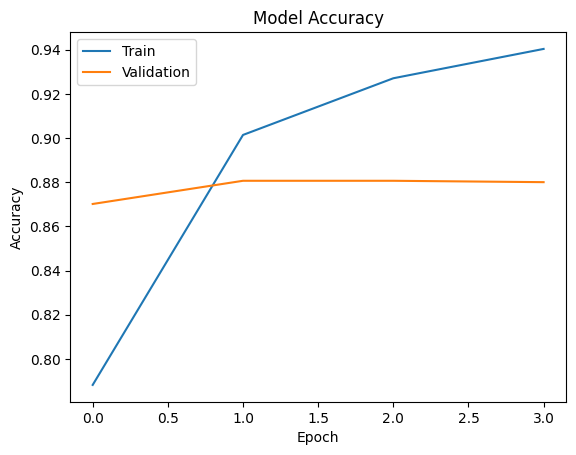

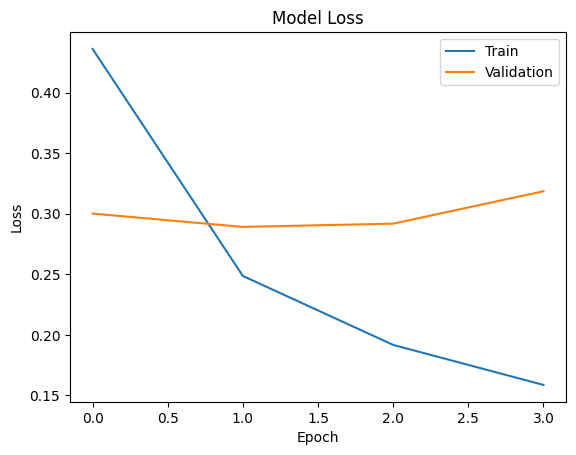

In [18]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()